**Importing Necessary Dependencies**

In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Data Collection**

In [182]:
# load the dataset into a pandas DataFrame
df = pd.read_csv("../dataset/clean dataset/telco_customer_churn_cleaned_dataset.csv")

In [183]:
# display first 5 rows of the dataset
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paper_less_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [184]:
df.shape

(7032, 21)

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         7032 non-null   object 
 1   gender              7032 non-null   object 
 2   senior_citizen      7032 non-null   int64  
 3   partner             7032 non-null   object 
 4   dependents          7032 non-null   object 
 5   tenure              7032 non-null   int64  
 6   phone_service       7032 non-null   object 
 7   multiple_lines      7032 non-null   object 
 8   internet_service    7032 non-null   object 
 9   online_security     7032 non-null   object 
 10  online_backup       7032 non-null   object 
 11  device_protection   7032 non-null   object 
 12  tech_support        7032 non-null   object 
 13  streaming_tv        7032 non-null   object 
 14  streaming_movies    7032 non-null   object 
 15  contract            7032 non-null   object 
 16  paper_

In [186]:
df.describe()

,senior_citizen,tenure,monthly_charges,total_charges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [187]:
df.duplicated().sum()

np.int64(0)

In [188]:
df.isnull().sum()

customer_id           0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paper_less_billing    0
payment_method        0
monthly_charges       0
total_charges         0
churn                 0
dtype: int64

**Exploratory Data Analysis (EDA)**

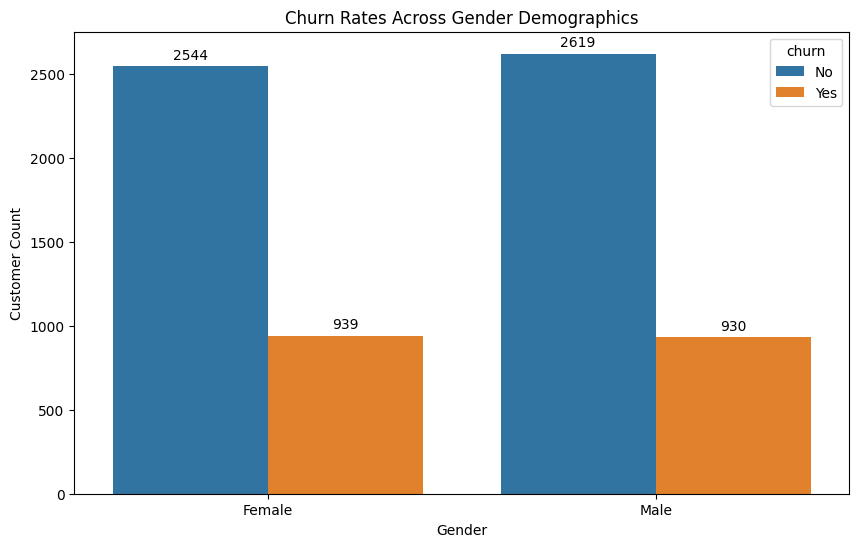

In [189]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x="gender", hue='churn', data=df)

# Add label counts on top of the bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge",padding=3)

plt.title("Churn Rates Across Gender Demographics")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.show()

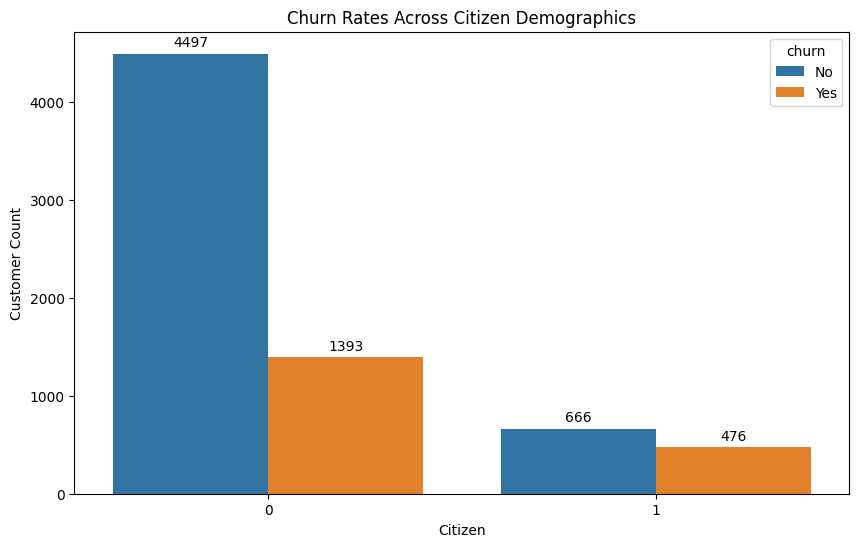

In [190]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x="senior_citizen", hue='churn', data=df)

# Add label counts on top of the bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge",padding=3)

plt.title("Churn Rates Across Citizen Demographics")
plt.xlabel("Citizen")
plt.ylabel("Customer Count")
plt.show()

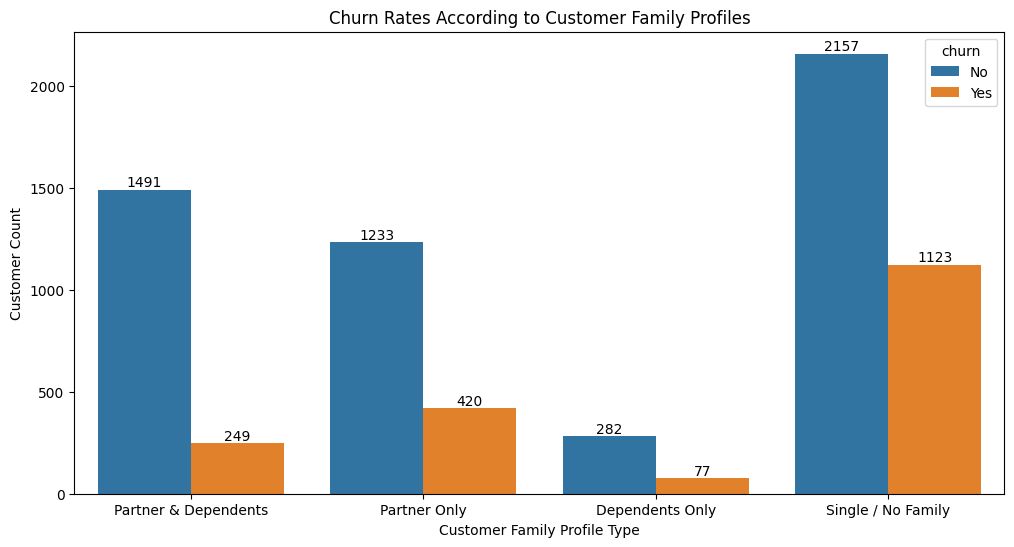

In [191]:
def get_customer_profile(row):
    if row['partner'] == 'Yes' and row['dependents'] == 'Yes':
        return 'Partner & Dependents'
    
    elif row['partner'] == 'Yes' and row['dependents'] == 'No':
        return 'Partner Only'
    
    elif row['partner'] == 'No' and row['dependents'] == 'Yes':
        return 'Dependents Only'
    
    else:
        return 'Single / No Family'

df['customer_profile'] = df.apply(get_customer_profile, axis=1)

plt.figure(figsize=(12,6))
ax= sns.countplot(x='customer_profile', hue='churn', data=df, order = ['Partner & Dependents', 'Partner Only', 'Dependents Only', 'Single / No Family'])

for container in ax.containers:
    ax.bar_label(container, label_type='edge')

plt.title("Churn Rates According to Customer Family Profiles")
plt.xlabel("Customer Family Profile Type")
plt.ylabel("Customer Count")
plt.show()

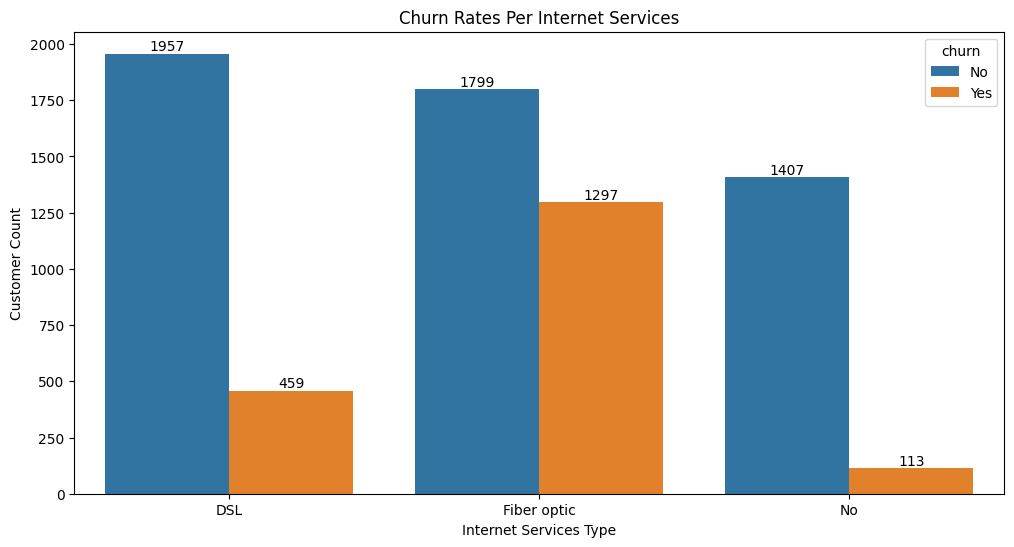

In [192]:
plt.figure(figsize=(12.,6))
ax=sns.countplot(data=df, x="internet_service", hue = "churn")

for container in ax.containers:
    ax.bar_label(container, label_type='edge')

plt.title("Churn Rates Per Internet Services")
plt.xlabel("Internet Services Type")
plt.ylabel("Customer Count")
plt.show()

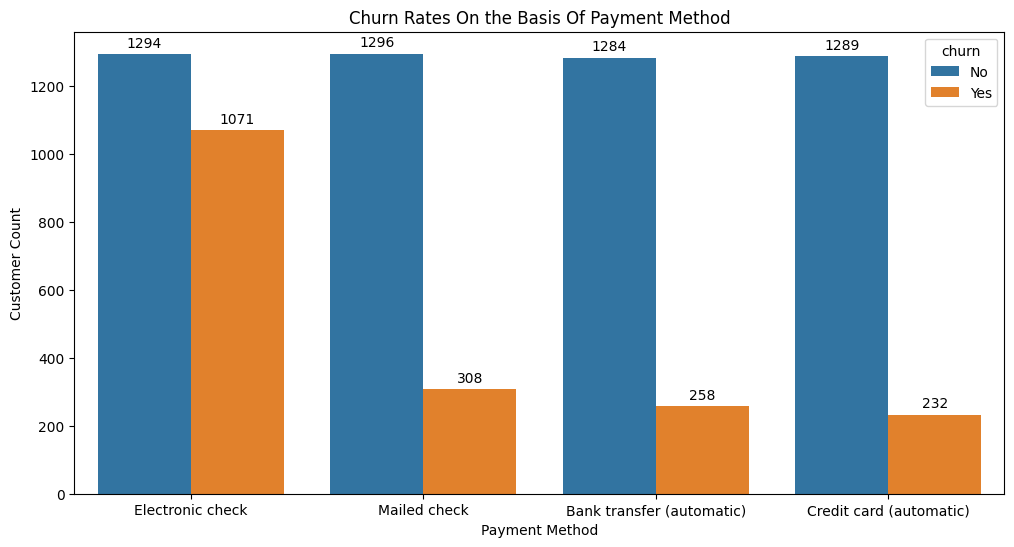

In [193]:
plt.figure(figsize=(12.,6))
ax=sns.countplot(data=df, x="payment_method", hue = "churn")

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding = 3)

plt.title("Churn Rates On the Basis Of Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.show()

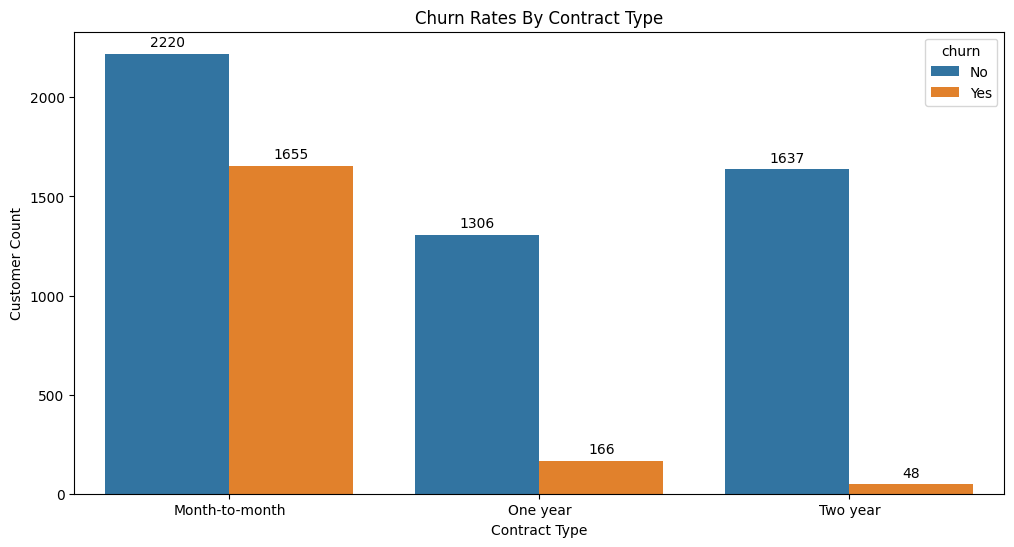

In [194]:
plt.figure(figsize=(12.,6))
ax=sns.countplot(data=df, x="contract", hue = "churn")

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding = 3)

plt.title("Churn Rates By Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.show()